# Data Exploration and Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv('student-scores.csv')
df.head(5)

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [3]:
df.columns

Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score'],
      dtype='str')

In [4]:
# Since id, name, email are unique values, I just dropped
new_df = df.drop(['id','first_name','last_name','email'], axis = 1)
new_df.head(5)

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [5]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   gender                      2000 non-null   str  
 1   part_time_job               2000 non-null   bool 
 2   absence_days                2000 non-null   int64
 3   extracurricular_activities  2000 non-null   bool 
 4   weekly_self_study_hours     2000 non-null   int64
 5   career_aspiration           2000 non-null   str  
 6   math_score                  2000 non-null   int64
 7   history_score               2000 non-null   int64
 8   physics_score               2000 non-null   int64
 9   chemistry_score             2000 non-null   int64
 10  biology_score               2000 non-null   int64
 11  english_score               2000 non-null   int64
 12  geography_score             2000 non-null   int64
dtypes: bool(2), int64(9), str(2)
memory usage: 175.9 KB


In [6]:
new_df.isnull().sum()

gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

In [7]:
new_df.columns

Index(['gender', 'part_time_job', 'absence_days', 'extracurricular_activities',
       'weekly_self_study_hours', 'career_aspiration', 'math_score',
       'history_score', 'physics_score', 'chemistry_score', 'biology_score',
       'english_score', 'geography_score'],
      dtype='str')

In [8]:
# Checking outliners
def outliers_detection(col):
    Q1 = new_df[col].quantile(0.25)
    Q3 = new_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5* IQR
    upper = Q3 + 1.5* IQR

    outliers = new_df[(new_df[col]<lower) | (df[col] >upper)]
    return outliers.shape[0]

print(f"Absence days outliers:", outliers_detection('absence_days'))
print(f"Self_study hour outliers:", outliers_detection('weekly_self_study_hours'))
print(f"Math Score outliers:", outliers_detection('math_score'))
print(f"History Score outliers:", outliers_detection('history_score'))
print(f"Physics Score outliers:", outliers_detection('physics_score'))
print(f"Chemistry Score outliers:", outliers_detection('chemistry_score'))
print(f"Biology Score outliers:", outliers_detection('biology_score'))
print(f"English Score outliers:", outliers_detection('english_score'))
print(f"Geography Score outliers:", outliers_detection('geography_score'))

Absence days outliers: 88
Self_study hour outliers: 0
Math Score outliers: 70
History Score outliers: 0
Physics Score outliers: 0
Chemistry Score outliers: 0
Biology Score outliers: 13
English Score outliers: 0
Geography Score outliers: 0


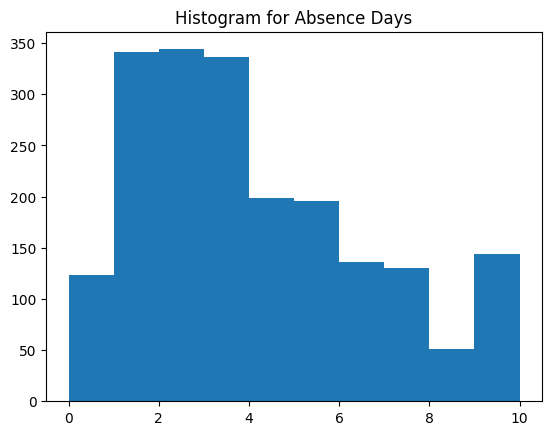

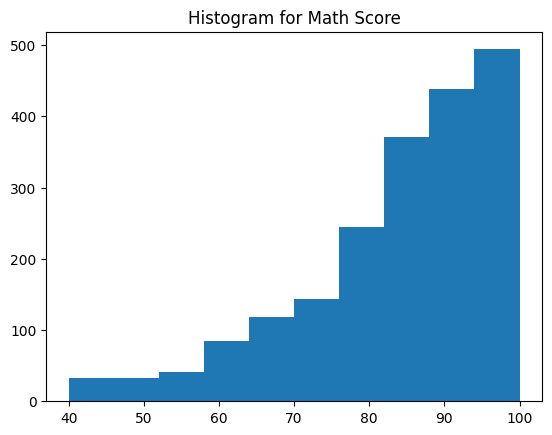

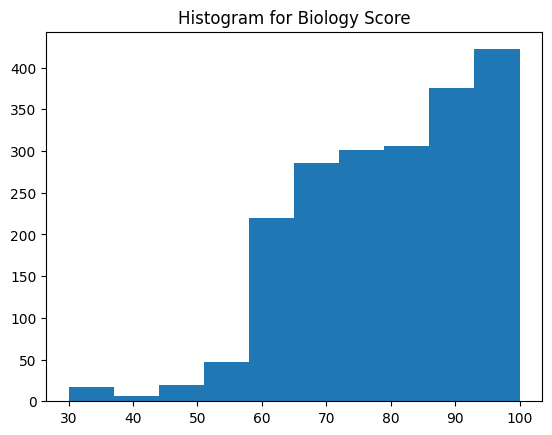

In [9]:
# Outliers Visualization 
new_df['absence_days'].hist(bins=10)
plt.title("Histogram for Absence Days")
plt.grid(False)
plt.show()

new_df['math_score'].hist(bins=10)
plt.title("Histogram for Math Score")
plt.grid(False)
plt.show()

new_df['biology_score'].hist(bins=10)
plt.title("Histogram for Biology Score")
plt.grid(False)
plt.show()


In [10]:
new_df.describe()

,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000
std,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705
min,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000
25%,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.00000,72.000000,71.000000
50%,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.00000,83.000000,81.000000
75%,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.00000,91.000000,91.000000
max,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000


Based on histogram visualization and data summary , the outliers are acceptable

# Data Preprocessing and Training

In [59]:
num_col = new_df.select_dtypes(include=['int64'])
cat_col = new_df.select_dtypes(include=['object','bool']).copy()

scaler = StandardScaler()
scaled_num_col = scaler.fit_transform(num_col)  

enc = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
encoded_cat_col = enc.fit_transform(cat_col) 

C:\Users\USER\AppData\Local\Temp\ipykernel_18728\446750177.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = new_df.select_dtypes(include=['object','bool']).copy()


In [61]:
X_preprocessed = np.hstack([scaled_num_col, encoded_cat_col])
print("Shape of preprocessed data:", X_preprocessed.shape)

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X_preprocessed)

Shape of preprocessed data: (2000, 28)


In [62]:
agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X_preprocessed)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


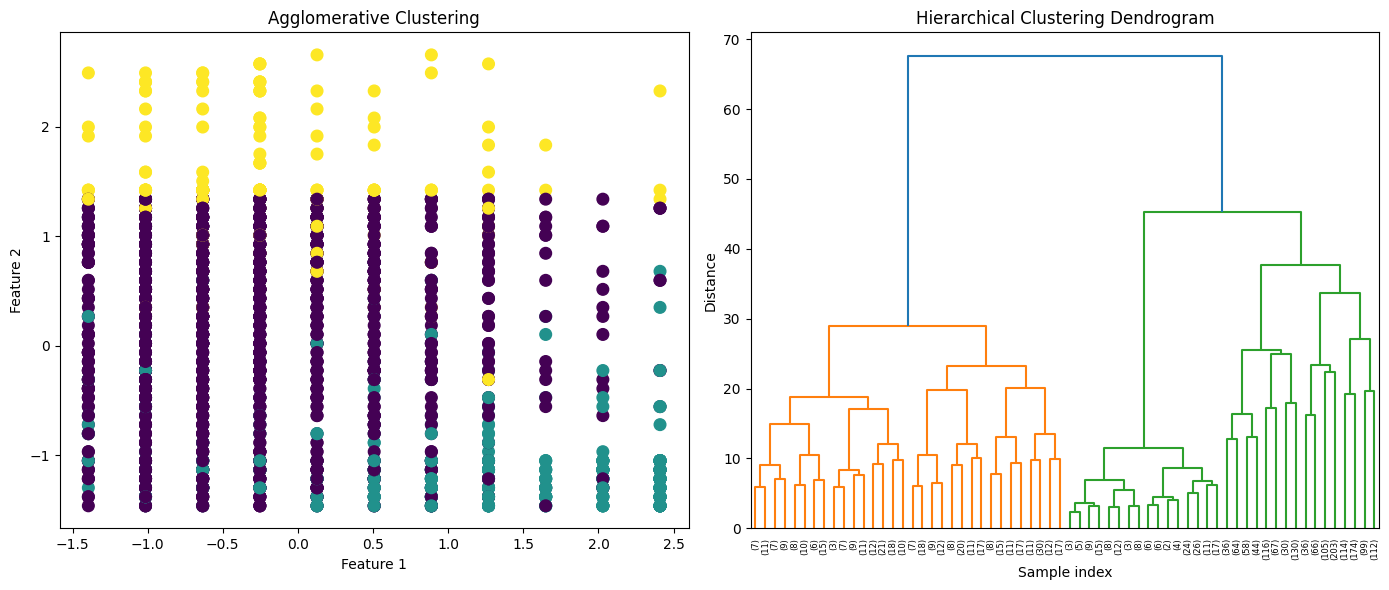

In [64]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X_preprocessed[:, 0], X_preprocessed[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()


Clusters: 2, Silhouette Score: 0.1715
Clusters: 3, Silhouette Score: 0.0584
Clusters: 4, Silhouette Score: 0.0442
Clusters: 5, Silhouette Score: 0.0415
Clusters: 6, Silhouette Score: 0.0422
Clusters: 7, Silhouette Score: 0.0386
Clusters: 8, Silhouette Score: 0.0370
Clusters: 9, Silhouette Score: 0.0383
Clusters: 10, Silhouette Score: 0.0414


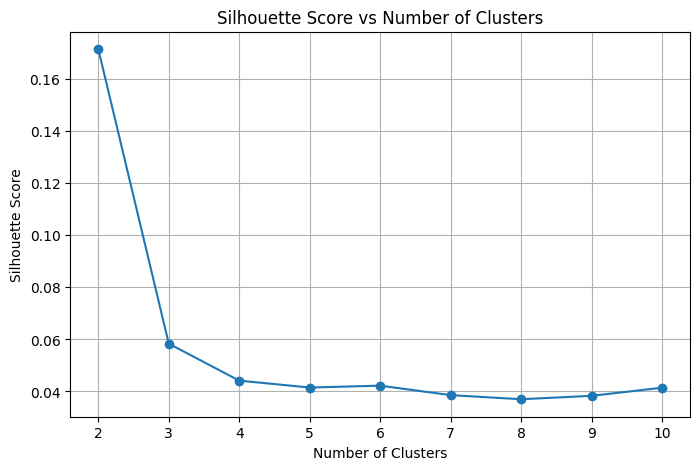

In [66]:
from sklearn.metrics import silhouette_score
cluster_range = range(2, 11)  

silhouette_scores = []

for n_clusters in cluster_range:
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(X_preprocessed)
    
    sil_score = silhouette_score(X_preprocessed, labels)
    silhouette_scores.append(sil_score)
    print(f"Clusters: {n_clusters}, Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [68]:
best_n_clusters = cluster_range[np.argmax(silhouette_scores)]
print("Best number of clusters (Silhouette):", best_n_clusters)

Best number of clusters (Silhouette): 2


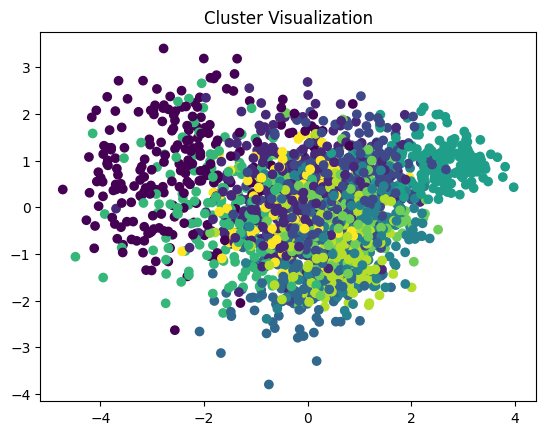

In [67]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_preprocessed)

plt.scatter(X_2d[:,0], X_2d[:,1], c=clustering.labels_, cmap='viridis')
plt.title("Cluster Visualization")
plt.show()

# Final Evaluation --> best cluster number is 2 

C:\Users\USER\AppData\Local\Temp\ipykernel_9260\1964054538.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df_clean.select_dtypes(include=['object', 'bool']).columns


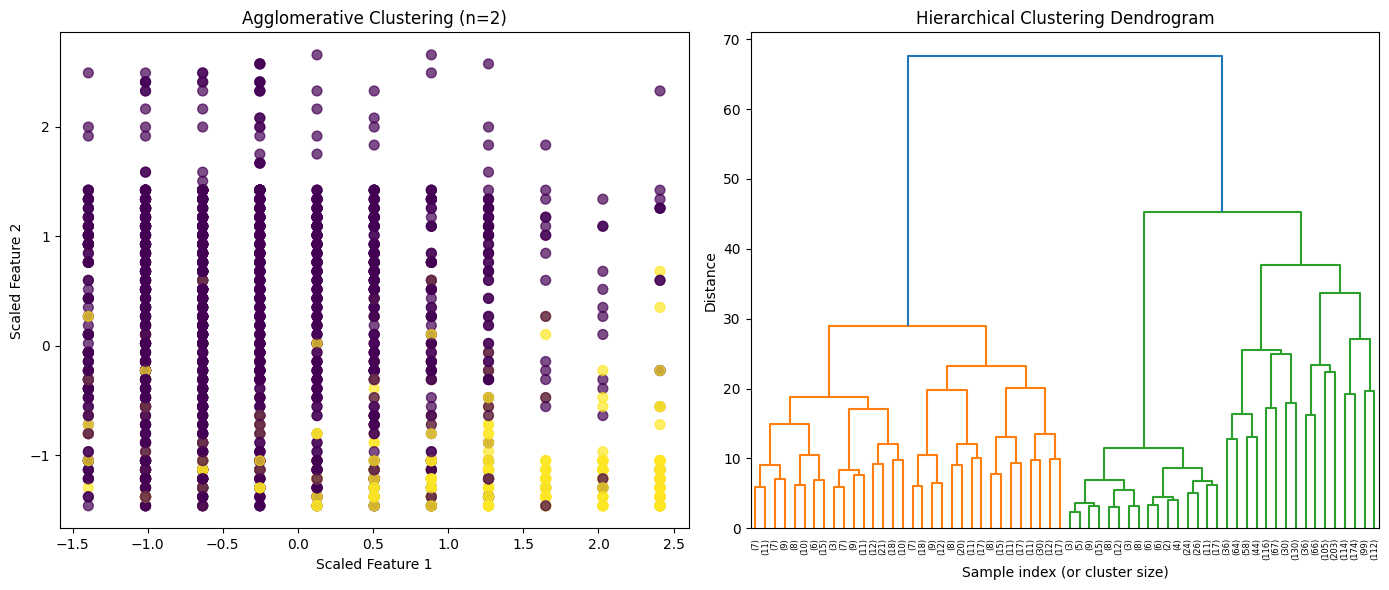

Model saved and plots generated.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from scipy.cluster.hierarchy import dendrogram
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import AgglomerativeClustering

# 1. Custom Dendrogram Function
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

# 2. Data Preparation
df = pd.read_csv('student-scores.csv')
df_clean = df.drop(columns=['id', 'first_name', 'last_name', 'email'])

numeric_features = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df_clean.select_dtypes(include=['object', 'bool']).columns

# 3. Pipeline Construction
# Note: compute_distances=True is REQUIRED for the dendrogram to work
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

clustering_model = AgglomerativeClustering(n_clusters=2, compute_distances=True)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', clustering_model)
])

# 4. Execute
# Get preprocessed data for plotting and fit the model
X_preprocessed = pipeline.named_steps['preprocessor'].fit_transform(df_clean)
labels = pipeline.named_steps['clusterer'].fit_predict(X_preprocessed)

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter Plot (using first two scaled features)
ax1.scatter(X_preprocessed[:, 0], X_preprocessed[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
ax1.set_title("Agglomerative Clustering (n=2)")
ax1.set_xlabel("Scaled Feature 1")
ax1.set_ylabel("Scaled Feature 2")

# Dendrogram
plt.sca(ax2)
plot_dendrogram(pipeline.named_steps['clusterer'], truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index (or cluster size)")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

# 6. Save Model
joblib.dump(pipeline, 'student_clustering_pipeline.pkl')
print("Model saved and plots generated.")

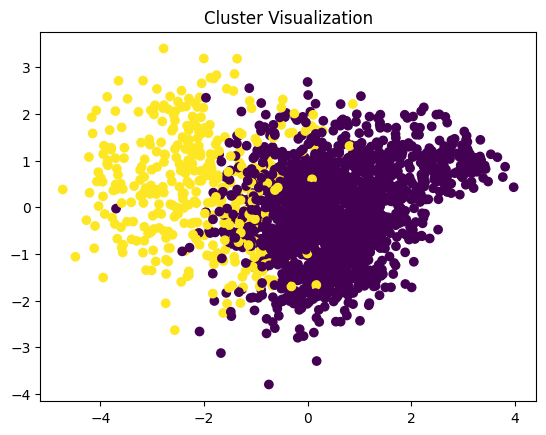

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_preprocessed)

plt.scatter(X_2d[:,0], X_2d[:,1], c=clustering_model.labels_, cmap='viridis')
plt.title("Cluster Visualization")
plt.show()

# PCA dropping 7 columns

In [5]:
df.columns

Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score',
       'cluster_label'],
      dtype='object')

In [15]:
import pandas as pd
import numpy as np
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA   

df = pd.read_csv('student-scores.csv')
df_clean = df.drop(columns=['id', 'first_name', 'last_name', 'email','gender','part_time_job','extracurricular_activities','career_aspiration'])

numeric_features = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df_clean.select_dtypes(include=['object', 'bool']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

clustering_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),  
    ('clusterer', AgglomerativeClustering(n_clusters=3))
])

df['cluster_label'] = clustering_pipeline.fit_predict(df_clean)


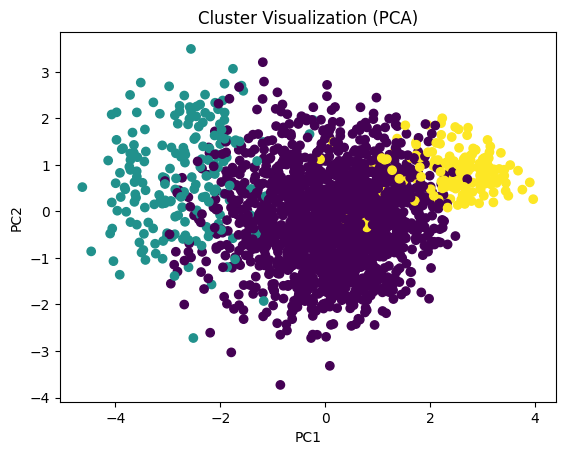

In [16]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_processed = clustering_pipeline.named_steps['preprocessor'].transform(df_clean)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_processed)

labels = clustering_pipeline.named_steps['clusterer'].labels_

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Clusters: 2, Silhouette Score: 0.3115
Clusters: 3, Silhouette Score: 0.3217
Clusters: 4, Silhouette Score: 0.3182
Clusters: 5, Silhouette Score: 0.2630
Clusters: 6, Silhouette Score: 0.2711
Clusters: 7, Silhouette Score: 0.2750
Clusters: 8, Silhouette Score: 0.2731
Clusters: 9, Silhouette Score: 0.2675
Clusters: 10, Silhouette Score: 0.2713


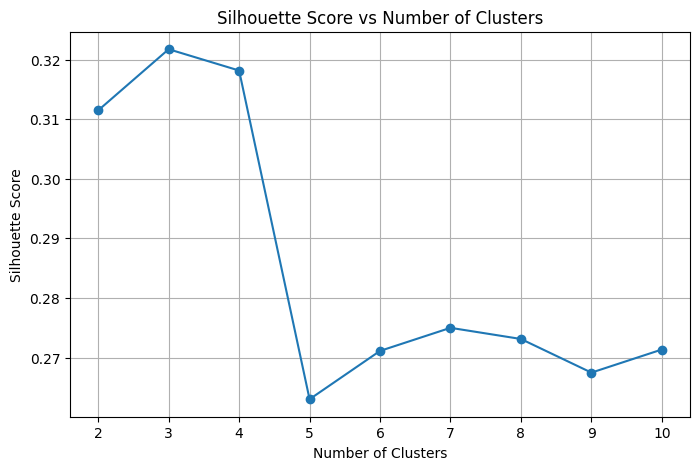

In [14]:
from sklearn.metrics import silhouette_score
cluster_range = range(2, 11)  

silhouette_scores = []

for n_clusters in cluster_range:
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(X_2d)
    
    sil_score = silhouette_score(X_2d, labels)
    silhouette_scores.append(sil_score)
    print(f"Clusters: {n_clusters}, Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [17]:
import pandas as pd
print(pd.__version__)

2.3.2
